In [1]:
import pandas as pd
import requests as req
import numpy
import matplotlib.pyplot as plt
import statistics
import seaborn as sns
from scipy.stats import kurtosis
from azure.storage.blob import BlobClient, BlobType, BlobServiceClient
from pathlib import Path
import os
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.arima.model import ARIMA
# from pyspark.sql import SparkSession
from datetime import datetime

In [25]:
from_date = input("enter from year and month hypen separated:")
to_date = input("enter to year and month hypen separated:")
country_code = input("enter three letter country code in capital")

power_generation_url = f"https://api.ember-energy.org/v1/electricity-generation/monthly?entity_code={country_code}&is_aggregate_entity=false&start_date={from_date}&end_date={to_date}&is_aggregate_series=false&include_all_dates_value_range=false&api_key=5133a418-c03e-d687-ad4f-0494aa83f387"
json_repsonse = req.get(power_generation_url)
print(json_repsonse.json()['data'])
power_df = pd.DataFrame(json_repsonse.json()['data'])
# power_df['updated_on'] = pd.to_datetime(power_df['updated_on'], unit='ms')
power_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']].head()
power_source = input("Enter source of power: ")
print(type(json_repsonse))
#unified_power_dataset = open("unified_power_generation_dataset.csv", 'a')
power_df.to_csv("E:\\India-Power-Capacity-DE\\"+power_df['entity'][0]+"_power_generation_dataset.csv", index=False)

[{'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2019-01-01', 'series': 'Bioenergy', 'is_aggregate_series': False, 'generation_twh': 2.58, 'share_of_generation_pct': 2.34}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2019-01-01', 'series': 'Coal', 'is_aggregate_series': False, 'generation_twh': 86.37, 'share_of_generation_pct': 78.2}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2019-01-01', 'series': 'Gas', 'is_aggregate_series': False, 'generation_twh': 3.97, 'share_of_generation_pct': 3.6}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2019-01-01', 'series': 'Hydro', 'is_aggregate_series': False, 'generation_twh': 7.8, 'share_of_generation_pct': 7.06}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2019-01-01', 'series': 'Net imports', 'is_aggregate_series': False, 'generation_twh': -0.75, 'share_of_generation_

In [26]:
start_time = datetime.now()
power_source_df = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0)]
power_source_df.head()

,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,generation_twh,share_of_generation_pct
2,India,IND,False,2019-01-01,Gas,False,3.97,3.60
12,India,IND,False,2019-02-01,Gas,False,3.20,3.16
22,India,IND,False,2019-03-01,Gas,False,3.73,3.19
32,India,IND,False,2019-04-01,Gas,False,4.21,3.53
42,India,IND,False,2019-05-01,Gas,False,4.45,3.44


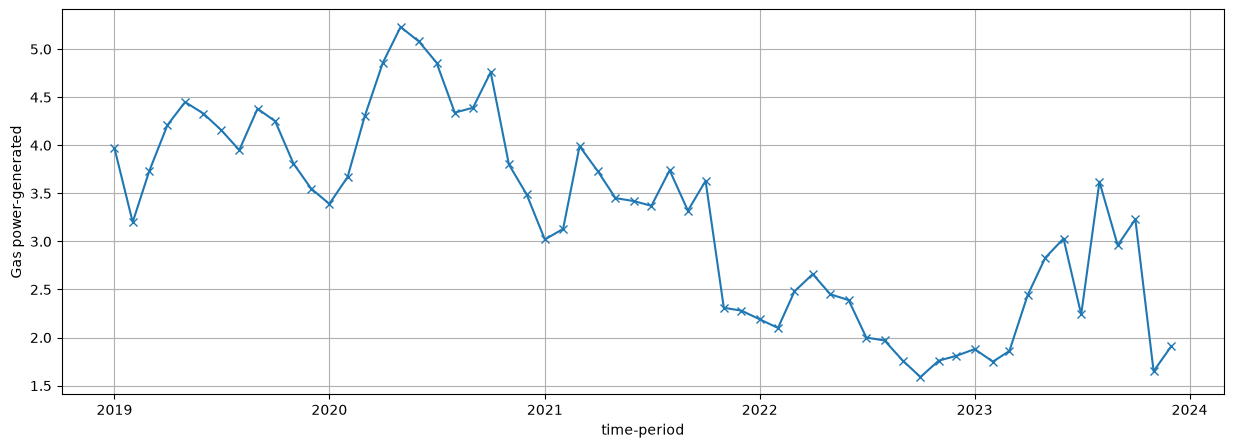

In [27]:
power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(15)
power_gen_fig.set_figheight(5)

x_axis_points = numpy.array(pd.DatetimeIndex(power_source_df['date']))
y_axis_points = numpy.array(power_source_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel(power_source+' power-generated')

# plt.bar(x_axis_points, y_axis_points, color="green")
plt.plot(x_axis_points, y_axis_points, marker = 'x')
plt.grid()


In [28]:
year_set = set()
for row in power_source_df.iterrows():
    year_set.update(pd.DatetimeIndex(power_source_df['date']).year)

yr_mm_dict = dict()

for i in year_set:
    mm_ls = list() 
    for date_val in power_source_df['date']:        
        if(pd.Timestamp(date_val).year == i):            
            mm_ls.append(pd.Timestamp(date_val).month)        
    yr_mm_dict[i] = mm_ls

print(yr_mm_dict)
print(year_set)
power_df.head()

# print(year_set)
# print(power_source_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())
    

{2019: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2020: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2021: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2022: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2023: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
{2019, 2020, 2021, 2022, 2023}


,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,generation_twh,share_of_generation_pct
0,India,IND,False,2019-01-01,Bioenergy,False,2.58,2.34
1,India,IND,False,2019-01-01,Coal,False,86.37,78.20
2,India,IND,False,2019-01-01,Gas,False,3.97,3.60
3,India,IND,False,2019-01-01,Hydro,False,7.80,7.06
4,India,IND,False,2019-01-01,Net imports,False,-0.75,-0.68


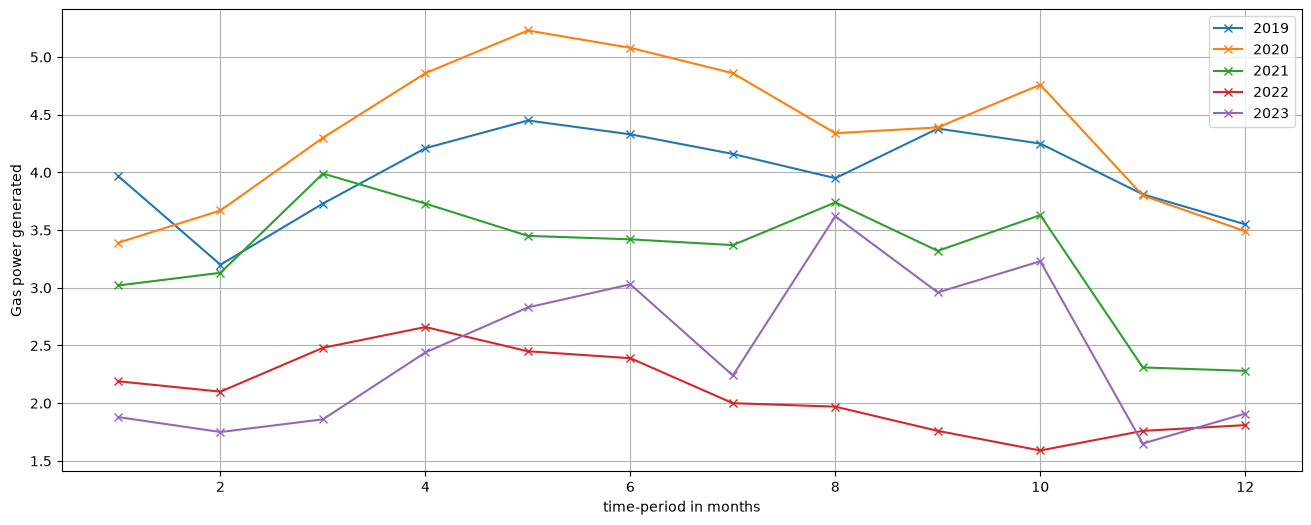

In [29]:
power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(16)
power_gen_fig.set_figheight(6)

plt.grid()

plt.xlabel("time-period in months")
plt.ylabel(power_source+ " power generated")


for yr in year_set:
    power_source_df = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == yr)]
    power_source_df[['date','series', 'generation_twh']].head()
    x_axis_points = numpy.array(pd.DatetimeIndex(power_source_df['date']).month)
    y_axis_points = numpy.array(power_source_df['generation_twh'])
    plt.plot(x_axis_points, y_axis_points, marker = 'x', label=str(yr))
    plt.legend()

Standard Deviation =  0.374516860485451
Mean =  3.9991666666666665
Variance =  0.1402628787878788
Standard Deviation =  0.6343088579491283
Mean =  4.3475
Variance =  0.4023477272727274
Standard Deviation =  0.5334131095638216
Mean =  3.2825
Variance =  0.2845295454545455
Standard Deviation =  0.34043644002510914
Mean =  2.0966666666666667
Variance =  0.11589696969696972
Standard Deviation =  0.664488867134322
Mean =  2.45
Variance =  0.4415454545454546


<Figure size 1600x600 with 0 Axes>

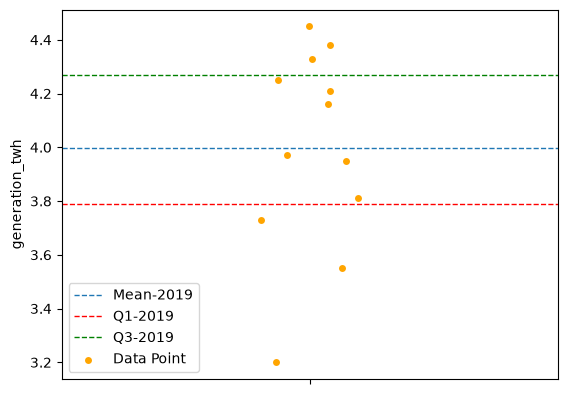

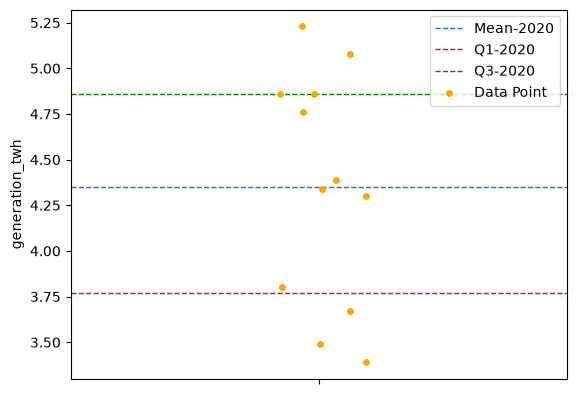

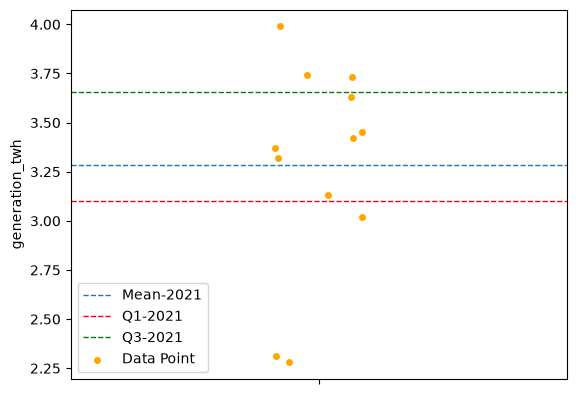

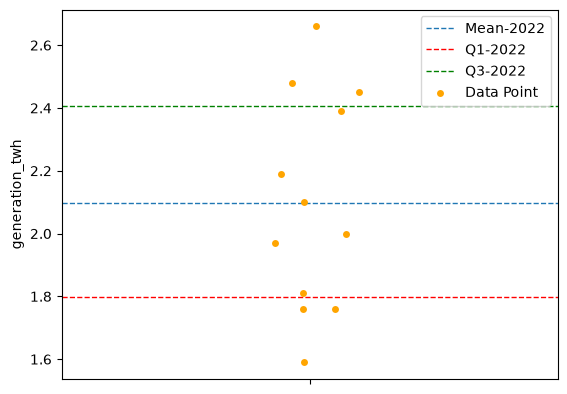

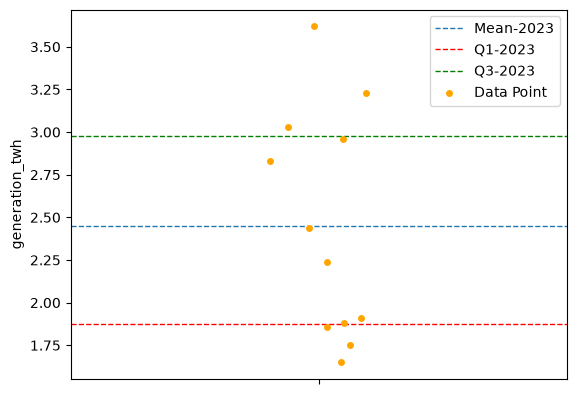

In [30]:
current_power_source = pd.DataFrame()

power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(16)
power_gen_fig.set_figheight(6)

def create_plots(mn, q_1, q_3, yr):
    plt.figure()

    plt.axhline(mn, linestyle='dashed', linewidth=1, label ='Mean-'+str(yr))
    plt.axhline(q_1, linestyle='dashed', linewidth=1, label='Q1-'+str(yr), color='red')
    plt.axhline(q_3, linestyle = 'dashed', linewidth=1, label='Q3-'+str(yr), color='green')
    sns.stripplot(current_power_source['generation_twh'], label = "Data Point", color='orange')

    plt.legend()

for y in year_set:
    current_power_source = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == y)]

    print("Standard Deviation = ",statistics.stdev(current_power_source['generation_twh']))
    print("Mean = ",statistics.mean(current_power_source['generation_twh']))

    print("Variance = ", statistics.variance(current_power_source['generation_twh']))
    std_dev = statistics.stdev(current_power_source['generation_twh'])
    mn = statistics.mean(current_power_source['generation_twh'])
    var = statistics.variance(current_power_source['generation_twh'])
    q_1 = numpy.quantile(current_power_source['generation_twh'], 0.25)
    q_3 = numpy.quantile(current_power_source['generation_twh'], 0.75)

    create_plots(mn, q_1, q_3, y)   


In [10]:
file_path = "E:\\India-Power-Capacity-DE\\"

for yr in year_set:
    df = power_df.loc[(power_source == power_df['series']) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == yr)]
    print(df[['series', 'generation_twh', 'date']])    
    f = open(file_path+power_source+"_power_generated"+"_"+str(yr),'a')
    df[['series', 'generation_twh', 'date']].to_csv(file_path+power_source+"_power_generated"+"_"+str(yr), index=False)
    f.close()
    file_name = power_source+"_power_generated"+"_"+str(yr)
    conn_string = ""
    # blb_service_client = BlobServiceClient.from_connection_string(conn_string)
    # container_client_obj = blb_service_client.get_container_client("yearly-power-generation")
    # with open(file = os.path.join("E:\\India-Power-Capacity-DE",file_name), mode="rb") as data:
    #     container_client_obj.upload_blob(name=file_name, data=data, overwrite=True)
    end_time = datetime.now()
    time_diff = (end_time-start_time).total_seconds()
    print(time_diff)
    # file_upload(power_source+"_power_generated"+"_"+str(yr))
    # with open(file_path+power_source+"_power_generated"+"_"+str(yr), 'a') as f:
        # df.to_csv()

    series  generation_twh        date
1     Coal           86.37  2019-01-01
11    Coal           78.20  2019-02-01
21    Coal           91.30  2019-03-01
31    Coal           90.44  2019-04-01
41    Coal           94.37  2019-05-01
51    Coal           89.88  2019-06-01
61    Coal           83.20  2019-07-01
71    Coal           76.83  2019-08-01
81    Coal           74.60  2019-09-01
91    Coal           74.86  2019-10-01
101   Coal           75.72  2019-11-01
111   Coal           82.77  2019-12-01
90.936947
    series  generation_twh        date
121   Coal           87.40  2020-01-01
131   Coal           85.62  2020-02-01
141   Coal           78.50  2020-03-01
151   Coal           61.94  2020-04-01
161   Coal           72.66  2020-05-01
171   Coal           73.06  2020-06-01
181   Coal           80.58  2020-07-01
191   Coal           74.69  2020-08-01
201   Coal           81.58  2020-09-01
211   Coal           84.89  2020-10-01
221   Coal           78.72  2020-11-01
231   Coal     

In [31]:
power_sector_emissions_url = f"https://api.ember-energy.org/v1/power-sector-emissions/monthly?entity_code={country_code}&is_aggregate_entity=false&start_date={from_date}&end_date={to_date}&series={power_source}&is_aggregate_series=false&include_all_dates_value_range=false&api_key=5133a418-c03e-d687-ad4f-0494aa83f387"
emission_api_response = req.get(power_sector_emissions_url).json()
emissions_df = pd.DataFrame(emission_api_response['data'])
emissions_df.merge(power_df, how="inner").head()

,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,emissions_mtco2,share_of_emissions_pct,generation_twh,share_of_generation_pct
0,India,IND,False,2019-01-01,Gas,False,2.75,3.32,3.97,3.60
1,India,IND,False,2019-02-01,Gas,False,2.21,2.96,3.20,3.16
2,India,IND,False,2019-03-01,Gas,False,2.59,2.97,3.73,3.19
3,India,IND,False,2019-04-01,Gas,False,2.92,3.37,4.21,3.53
4,India,IND,False,2019-05-01,Gas,False,3.08,3.42,4.45,3.44


<Figure size 2600x1800 with 0 Axes>

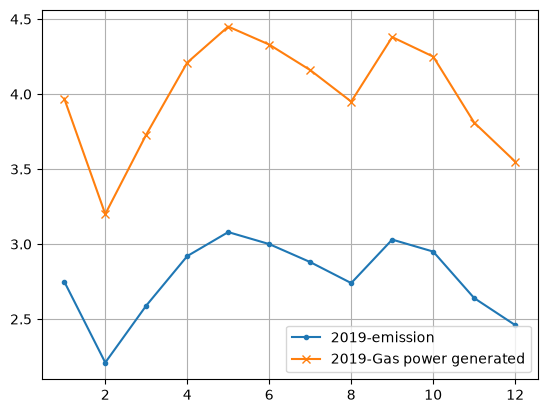

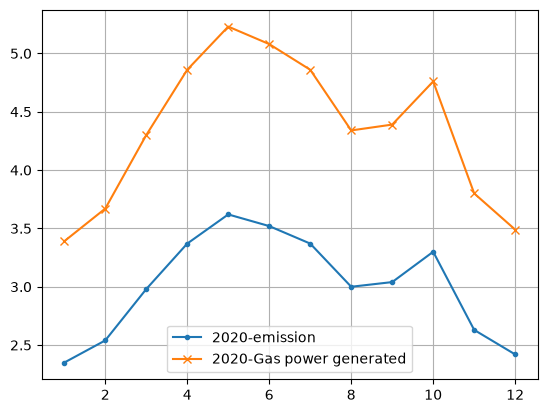

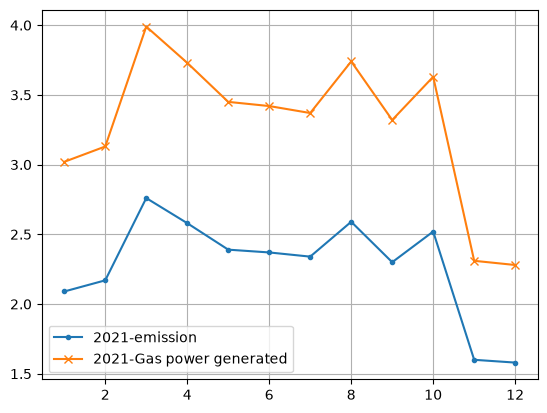

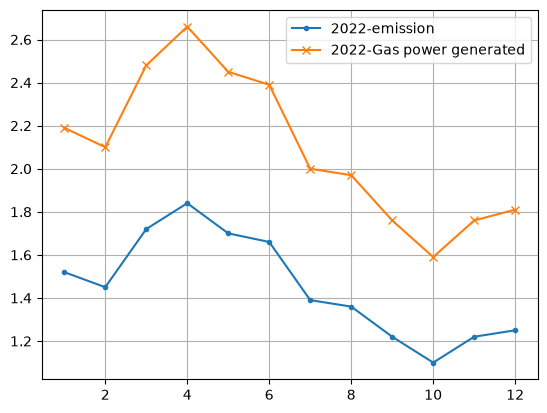

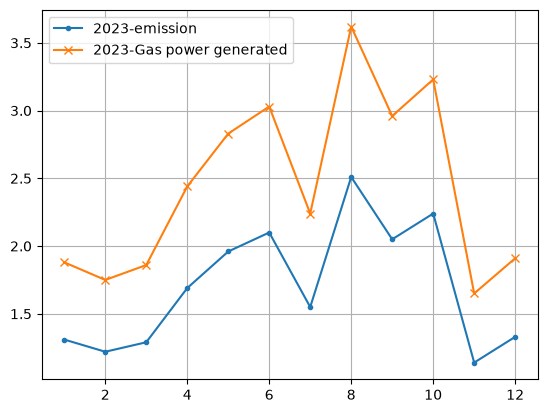

In [32]:
emission_fig = plt.figure()
emission_fig.set_figwidth(26)
emission_fig.set_figheight(18) 

for y in year_set:
    plt.figure()
     
    yearly_emission_df = emissions_df.loc[(pd.DatetimeIndex(emissions_df['date']).year == y)]
    x_axis_emission_points = numpy.array(pd.DatetimeIndex(yearly_emission_df['date']).month)
    y_axis_emission_points = numpy.array(yearly_emission_df['emissions_mtco2'])

    df = power_df.loc[(pd.DatetimeIndex(power_df['date']).year == y) & (power_df['series'] == power_source)]    
    x_axis_points = numpy.array(pd.DatetimeIndex(df['date']).month)
    y_axis_points = numpy.array(df['generation_twh'])
       
    plt.plot(x_axis_emission_points, y_axis_emission_points, label = str(y)+'-emission', marker = '.')
    plt.plot(x_axis_points, y_axis_points, label = str(y)+'-'+power_source+' power generated', marker = 'x')
       
    plt.grid()
    plt.legend()

In [ ]:
# print(current_power_source)
# for y in year_set:
#     df = power_df.loc[(power_source == power_df['series']) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == y)]
#     print(sorted(df['generation_twh']))
#     med = statistics.median(sorted(df['generation_twh']))
#     print("median = ", med)

#     q_1 = numpy.quantile(df['generation_twh'], 0.25)
#     q_2 = numpy.quantile(df['generation_twh'], 0.50)
#     q_3 = numpy.quantile(df['generation_twh'], 0.75)

#     print("Q1 = ", q_1)
#     print("Q2 = ", q_2)
#     print("Q3 = ", q_3)
    
#     plt.figure()
#     plt.axvline(med,linestyle="dashed")    

In [22]:
# training_power_source = power_df.loc[(power_df['generation_twh'] != 0) & (power_df['series'] == power_source)]
# training_power_source
# energy_model = ARIMA(training_power_source['generation_twh'], order=(4,3,1))
# model_fit= energy_model.fit()
# print(model_fit.forecast(steps=5))

# coal_data = training_power_source[training_power_source["series"] == "Coal"]
# print(coal_data.tail())

In [23]:
# gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]
# # print(gas_power_generation_2023['generation_twh'])
# gas_power_mean_2023 = statistics.mean(gas_power_generation_2023['generation_twh'])
# gas_power_median_2023 = statistics.median(sorted(gas_power_generation_2023['generation_twh']))
# gas_power_mode_2023 = statistics.mode(sorted(gas_power_generation_2023['generation_twh']))

# print(gas_power_mean_2023)
# print(gas_power_median_2023)
# print(gas_power_mode_2023)


# sns.kdeplot(gas_power_generation_2023['generation_twh'])
# plt.axvline(gas_power_mean_2023, label="Mean", color="red")
# plt.axvline(gas_power_median_2023, label = "Median", color="yellow")
# plt.axvline(gas_power_mode_2023, label = "Mode")
# plt.grid()
# plt.show()


In [24]:
# print(gas_df[['date', 'generation_twh']])
# print("Gas Year Wise generation")
# print(gas_df.groupby(pd.DatetimeIndex(gas_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Coal power year wise Generation")
# print(thermal_df.groupby(pd.DatetimeIndex(thermal_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Wind energy year wise generation")
# print(wind_df.groupby(pd.DatetimeIndex(wind_df['date']).year)['generation_twh'].sum())

# print("\n")
# print("Solar power generation year wise")
# print(solar_df.groupby(pd.DatetimeIndex(solar_df['date']).year)['generation_twh'].sum())

# date_df = pd.DatetimeIndex(power_df['date']).year
# print(date_df)
# series_df = power_df['series'].unique()

# print(power_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())


In [25]:
# kurtosis(gas_power_generation_2023['generation_twh'] ,axis = 0, fisher=True, bias=True)

# gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
# kurtosis(gas_power_generation_2024['generation_twh'])

In [26]:
# gas_power_generation_2025 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2025)]
# gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
# gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]

# print(kurtosis(gas_power_generation_2025['generation_twh']))
# print(kurtosis(gas_power_generation_2024['generation_twh']))
# print(kurtosis(gas_power_generation_2023['generation_twh']))

In [27]:
# sns.kdeplot(gas_power_generation_2025['generation_twh'], color="black")
# sns.kdeplot(gas_power_generation_2024['generation_twh'], color = "blue")
# sns.kdeplot(gas_power_generation_2023['generation_twh'], color= "green")
# plt.grid()

In [28]:
# def file_upload(file_name):
#     conn_string = "DefaultEndpointsProtocol=https;AccountName=indiapowerdata;AccountKey=Ngjt3Jhf8cTrB/OUXVIYP2tCdfhRqmhkZSKKMxyqVuddOKb+TOQ9kqpk5qri/WyprdcUoMiUgphh+AStUgpfSQ==;EndpointSuffix=core.windows.net"
#     blb_service_client = BlobServiceClient.from_connection_string(conn_string)
#     container_client_obj = blb_service_client.get_container_client("yearly-power-generation")
#     with open(file = os.path.join("E:\\India-Power-Capacity-DE",file_name), mode="rb") as data:
        # container_client_obj.upload_blob(name=file_name, data=data, overwrite=False)

In [29]:
# dates = power_source_df['date']
# months = pd.DatetimeIndex(power_source_df['date']).month
# date_df = pd.DataFrame(dates)
# pd.DataFrame(date_df.insert(1, "months",months, allow_duplicates=False))
# print(date_df)

In [30]:
# print(
#     power_df.groupby(
#             [pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].mean())

In [31]:
# sorted_power_df = power_df.sort_values(by='generation_twh', ascending=False)

# # print(sorted_power_df)

# sorted_power_df.loc[sorted_power_df['series'] == 'Coal'].head(3)

In [32]:
# sorted_power_df.groupby([pd.DatetimeIndex(sorted_power_df['date']).year, sorted_power_df['series']])['generation_twh'].sum()
# total_series_gen.max()

In [33]:
# sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].mean()

In [34]:
# sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].max()

In [35]:
# sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].min()

In [36]:
# sorted_power_df

In [37]:
# import sys
# print(sys.executable)
# print(sys.version)

In [38]:
# import sys

# print("Python:", sys.executable)
# print("Spark Python:", spark.sparkContext.getConf().get("spark.pyspark.python"))
# print("Driver Python:", spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

In [39]:
# import sys
# from pyspark.sql import SparkSession

# spark = (
#     SparkSession.builder
#     .master("local[*]")
#     .config("spark.pyspark.python", sys.executable)
#     .config("spark.pyspark.driver.python", sys.executable)
#     .getOrCreate()
# )

# print(spark.sparkContext.getConf().get("spark.pyspark.python"))
# print(spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

In [40]:
# spark.sparkContext._jsc.sc().isStopped()
# spark.sparkContext.getConf().getAll()

In [41]:
# import shutil
# print(shutil.which("python"))